In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

def load (path):
    df = pd.read_csv(path)
    return df

file_path = "/kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv"

df = load (file_path)

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [2]:
def check_nulls(df): 
 return df.isnull().sum()
    
print("Null values in each column:\n")
print(check_nulls(df))

Null values in each column:

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


In [3]:
def drop_columns(df):
    
    cols_to_drop = ["loan_id"]
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df

df = drop_columns(df)
print("Columns dropped successfully!")

Columns dropped successfully!


In [4]:
df.columns = df.columns.str.strip()


# EDA insights for Loan Status

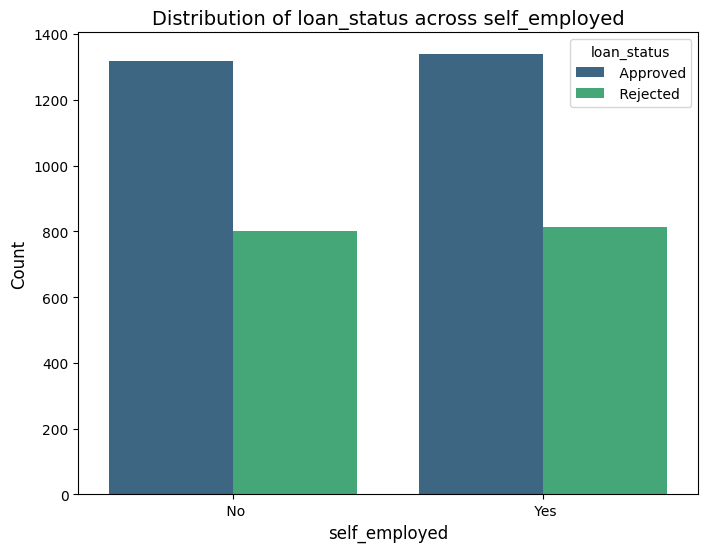

In [5]:
def plot_status_vs_self_employed(df, self_employed_col='self_employed', status_col='loan_status'):
    
    plt.figure(figsize=(8,6))
    sns.countplot(x=self_employed_col, hue=status_col, data=df, palette='viridis')
    plt.title(f'Distribution of {status_col} across {self_employed_col}', fontsize=14)
    plt.xlabel(self_employed_col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title=status_col)
    plt.show()

plot_status_vs_self_employed(df)

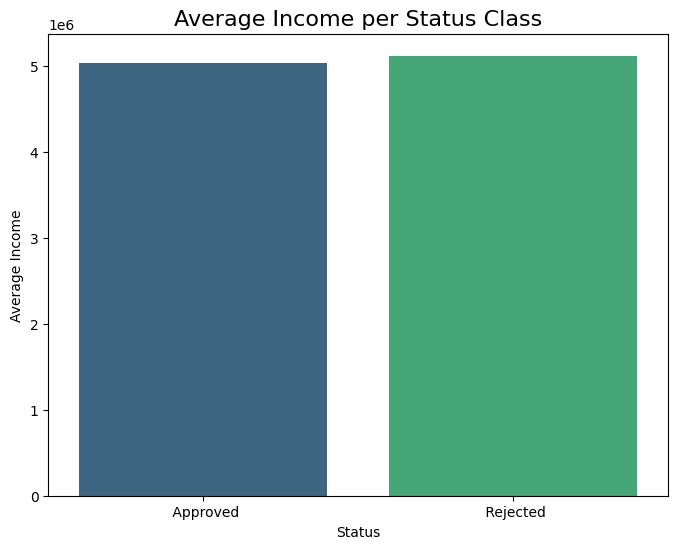

In [6]:
def plot_status_vs_income(df):
    
    plt.figure(figsize=(8,6))
    sns.barplot(x='loan_status', y='income_annum', data=df, ci=None, palette='viridis')
    plt.title('Average Income per Status Class', fontsize=16)
    plt.ylabel('Average Income')
    plt.xlabel('Status')
    plt.show()

plot_status_vs_income(df)

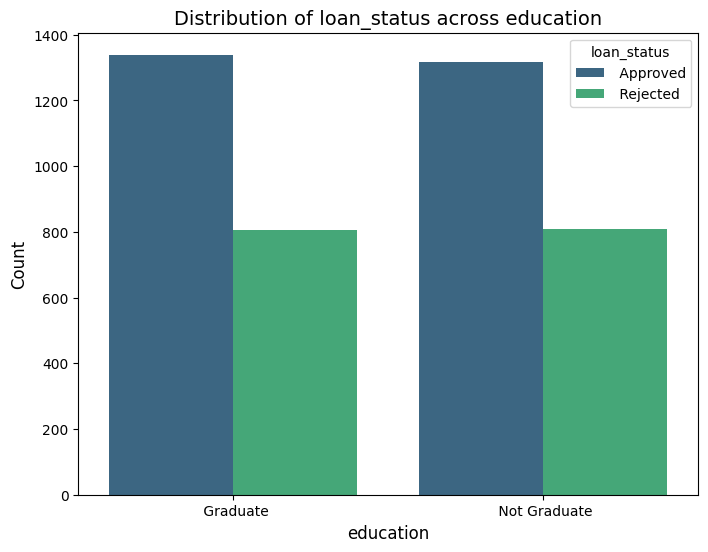

In [7]:
def plot_status_vs_education(df, education_col='education', status_col='loan_status'):
    
    plt.figure(figsize=(8,6))
    sns.countplot(x=education_col, hue=status_col, data=df, palette='viridis')
    plt.title(f'Distribution of {status_col} across {education_col}', fontsize=14)
    plt.xlabel(education_col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title=status_col)
    plt.show()

plot_status_vs_education(df)

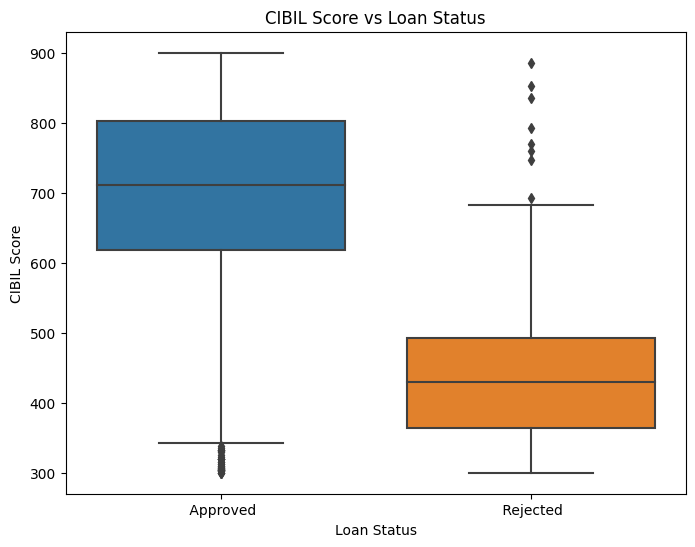

In [8]:
def plot_cibil_vs_status(df):
    plt.figure(figsize=(8,6))
    sns.boxplot(x='loan_status', y='cibil_score', data=df)
    plt.title("CIBIL Score vs Loan Status")
    plt.xlabel("Loan Status")
    plt.ylabel("CIBIL Score")
    plt.show()

plot_cibil_vs_status(df)

# Feature Engineering 

In [9]:
def encode_columns(df):
    cols_to_encode = ['loan_status', 'education', 'self_employed']
    le = LabelEncoder()
    for col in cols_to_encode:
        if col in df.columns:
            df[col] = le.fit_transform(df[col])
    return df

df = encode_columns(df)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [10]:
# Count of each class
status_counts = df['loan_status'].value_counts()
print("Counts per class:\n", status_counts)

# Percentage distribution
status_percent = df['loan_status'].value_counts(normalize=True) * 100
print("\nPercentage distribution:\n", status_percent)

Counts per class:
 loan_status
0    2656
1    1613
Name: count, dtype: int64

Percentage distribution:
 loan_status
0    62.215976
1    37.784024
Name: proportion, dtype: float64


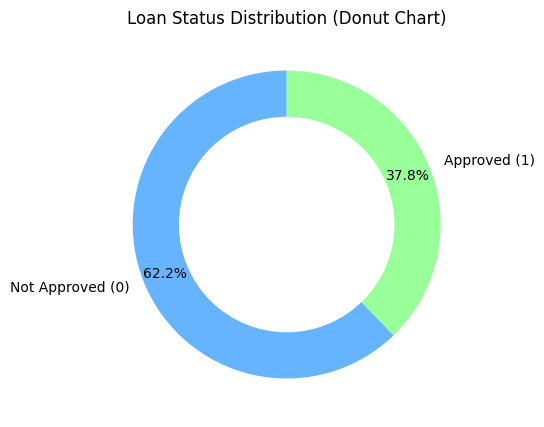

In [11]:
def plot_donut_chart():
    sizes = [62.215976, 37.784024]  
    labels = ["Not Approved (0)", "Approved (1)"]
    colors = ["#66b3ff", "#99ff99"]

    fig, ax = plt.subplots(figsize=(5,5))
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, colors=colors, autopct="%1.1f%%",
        startangle=90, pctdistance=0.85
    )

    # donut hole
    centre_circle = plt.Circle((0,0), 0.70, fc="white")
    fig.gca().add_artist(centre_circle)

    ax.set_title("Loan Status Distribution (Donut Chart)")
    plt.show()

plot_donut_chart()

In [12]:
def target_correlation(df, target_col='loan_status', method='pearson', top_n=None):
    
    corr_series = df.corr(method=method)[target_col].drop(target_col)
    corr_df = corr_series.to_frame().rename(columns={target_col:'correlation'})
    corr_df['abs_corr'] = corr_df['correlation'].abs()
    corr_df = corr_df.sort_values(by='abs_corr', ascending=False)
    
    if top_n:
        corr_df = corr_df.head(top_n)
    
    return corr_df

corr_with_status = target_correlation(df, target_col='loan_status', top_n=20)
print(corr_with_status)

                          correlation  abs_corr
cibil_score                 -0.770518  0.770518
loan_term                    0.113036  0.113036
no_of_dependents             0.018114  0.018114
loan_amount                 -0.016150  0.016150
luxury_assets_value          0.015465  0.015465
income_annum                 0.015189  0.015189
residential_assets_value     0.014367  0.014367
commercial_assets_value     -0.008246  0.008246
bank_asset_value             0.006778  0.006778
education                    0.004918  0.004918
self_employed               -0.000345  0.000345


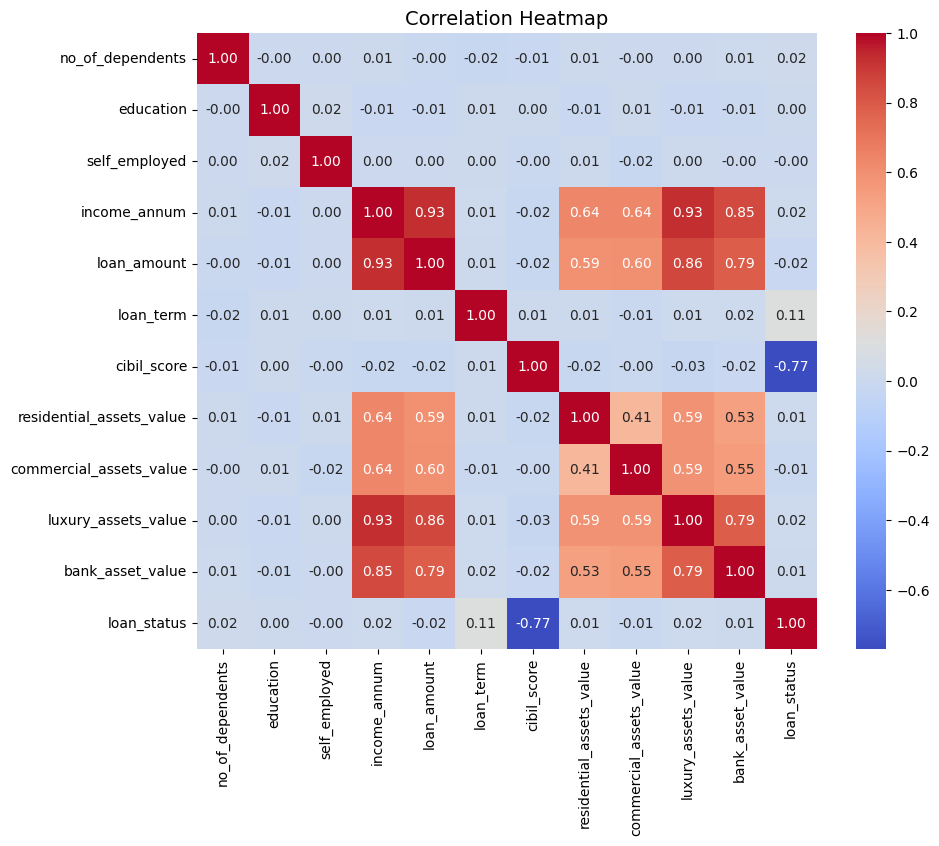

In [13]:
def plot_correlation_heatmap(df):
    plt.figure(figsize=(10, 8))
    corr = df.corr()   # correlation matrix
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
    plt.title("Correlation Heatmap", fontsize=14)
    plt.show()

plot_correlation_heatmap(df)

In [14]:
def scale_features(df):
    scaler = StandardScaler()
    cols_to_scale = [col for col in df.columns if col != 'loan_status']
    
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    return df

df = scale_features(df)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,-0.294102,-0.995559,-1.007288,1.617979,1.633052,0.192617,1.032792,-0.780058,2.877289,0.832028,0.930304,0
1,-1.473548,1.004461,0.992765,-0.341750,-0.324414,-0.508091,-1.061051,-0.733924,-0.631921,-0.694993,-0.515936,1
2,0.295621,-0.995559,-1.007288,1.439822,1.610933,1.594031,-0.544840,-0.057300,-0.107818,1.996520,2.407316,1
3,0.295621,-0.995559,-1.007288,1.119139,1.721525,-0.508091,-0.771045,1.649637,-0.381263,0.897943,0.899533,1
4,1.475067,1.004461,0.992765,1.689242,1.002681,1.594031,-1.264055,0.757724,0.735304,1.568075,0.007172,1


In [15]:
def stratified_split(df, target_col='loan_status', test_size=0.2, random_state=42):
    
    X = df.drop(columns=['loan_status'])
    y = df['loan_status']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        stratify=y, 
        random_state=random_state
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = stratified_split(df)

print("Train class distribution:\n", y_train.value_counts(normalize=True))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True))

Train class distribution:
 loan_status
0    0.622255
1    0.377745
Name: proportion, dtype: float64

Test class distribution:
 loan_status
0    0.62178
1    0.37822
Name: proportion, dtype: float64


# ML Modeling 

In [16]:
def run_logistic_regression(X_train, X_test, y_train, y_test):
    
    model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("=== Logistic Regression Results ===\n")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

    return model

X_train, X_test, y_train, y_test = stratified_split(df)
log_reg_model = run_logistic_regression(X_train, X_test, y_train, y_test)

=== Logistic Regression Results ===

Confusion Matrix:
 [[500  31]
 [ 24 299]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.95       531
           1       0.91      0.93      0.92       323

    accuracy                           0.94       854
   macro avg       0.93      0.93      0.93       854
weighted avg       0.94      0.94      0.94       854

ROC-AUC Score: 0.974835726737915


In [17]:
def run_xgboost(X_train, X_test, y_train, y_test):
  
    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # handle imbalance
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    )
   
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("=== XGBoost Results ===\n")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

    return model

X_train, X_test, y_train, y_test = stratified_split(df)
xgb_model = run_xgboost(X_train, X_test, y_train, y_test)

=== XGBoost Results ===

Confusion Matrix:
 [[527   4]
 [ 11 312]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

ROC-AUC Score: 0.9984141143820002


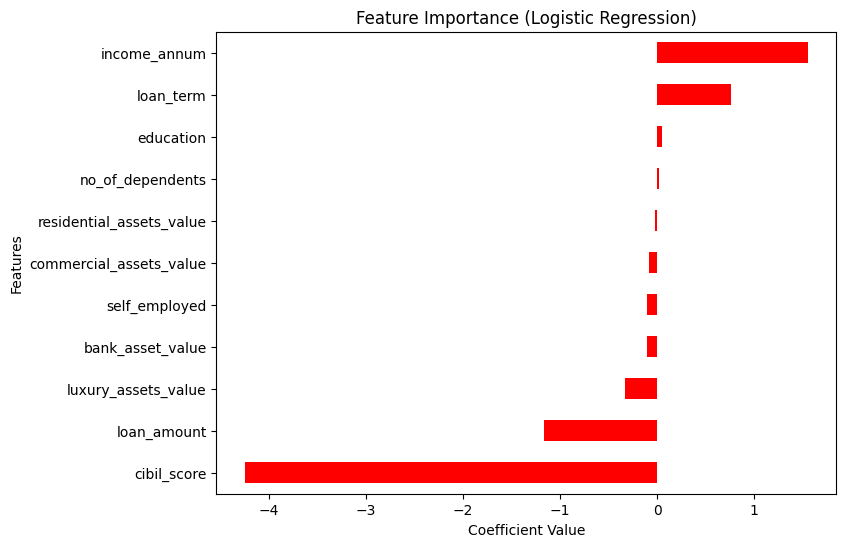

In [18]:
def plot_logistic_importance(model, feature_names):
    coefs = model.coef_[0]
    importance = pd.Series(coefs, index=feature_names).sort_values()

    plt.figure(figsize=(8,6))
    importance.plot(kind='barh', color='red')
    plt.title("Feature Importance (Logistic Regression)")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    plt.show()

plot_logistic_importance(log_reg_model, X_train.columns)

<Figure size 800x600 with 0 Axes>

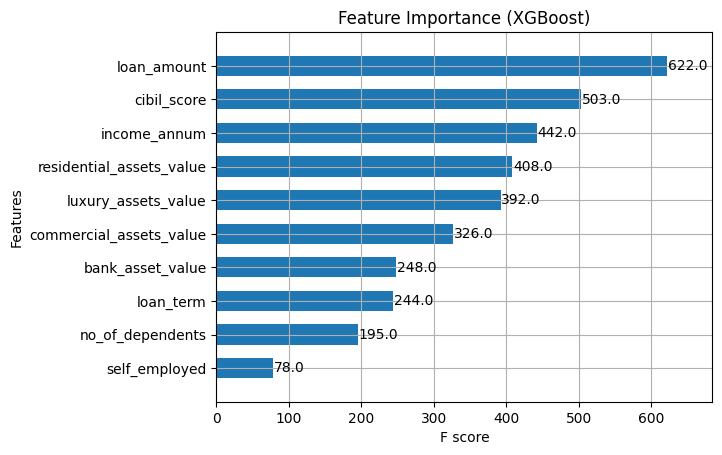

In [19]:
def plot_xgb_importance(model):
    plt.figure(figsize=(8,6))
    plot_importance(model, importance_type='weight', max_num_features=10, height=0.6)
    plt.title("Feature Importance (XGBoost)")
    plt.show()

plot_xgb_importance(xgb_model)

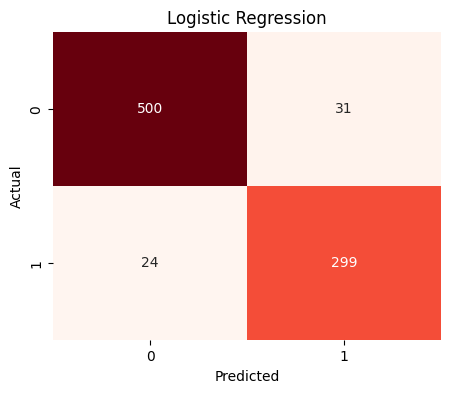

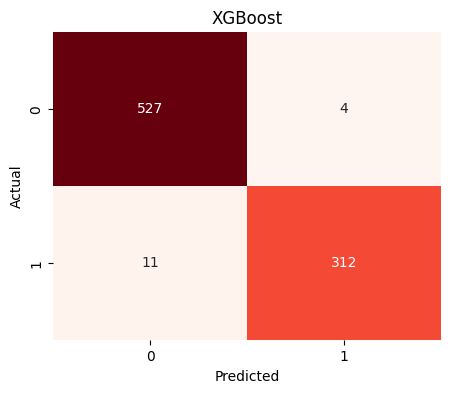

In [20]:
def plot_conf_matrix(model, X_test, y_test, title="Confusion Matrix"):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Logistic Regression confusion matrix
plot_conf_matrix(log_reg_model, X_test, y_test, title="Logistic Regression")

# XGBoost confusion matrix
plot_conf_matrix(xgb_model, X_test, y_test, title="XGBoost")

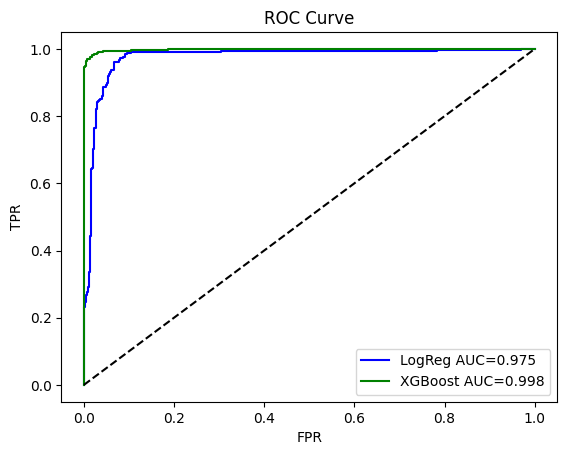

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc(log_reg, xgb, X_test, y_test):
    for model, name, color in [(log_reg,"LogReg","blue"), (xgb,"XGBoost","green")]:
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}", color=color)

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve")
    plt.legend(); plt.show()

plot_roc(log_reg_model, xgb_model, X_test, y_test)

# Cross-Validation of validation 

In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

def run_cross_validation(model, X, y, cv=5, scoring='roc_auc'):
    
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=skf, scoring=scoring)
    
    print(f"Cross-validation ({cv}-fold) {scoring}:")
    print("Scores:", scores)
    print("Mean:", np.mean(scores))
    print("Std:", np.std(scores))
    
    return scores

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
run_cross_validation(log_reg, X_train, y_train, cv=5, scoring='roc_auc')

xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    use_label_encoder=False, eval_metric="logloss"
)

run_cross_validation(xgb, X_train, y_train, cv=5, scoring='roc_auc')

Cross-validation (5-fold) roc_auc:
Scores: [0.96496124 0.96314637 0.96999544 0.96511628 0.96895577]
Mean: 0.9664350205198359
Std: 0.002598347720219505
Cross-validation (5-fold) roc_auc:
Scores: [0.99763794 0.99785682 0.99824897 0.99818513 0.99948016]
Mean: 0.9982818057455539
Std: 0.000639009540600776


array([0.99763794, 0.99785682, 0.99824897, 0.99818513, 0.99948016])

# Logistic Regression (5-fold CV, ROC-AUC):

Fold scores: ~0.963 – 0.970

Mean ROC-AUC ~0.966

Std ~0.0026 → stable model

# XGBoost (5-fold CV, ROC-AUC):

Fold scores: ~0.9976 – 0.9995

Mean ROC-AUC ~0.9983 

Std ~0.0006 → almost zero variance, very consistent

# Interpretation:

Logistic Regression → good baseline, but still weaker (~0.97 ROC-AUC).

XGBoost → (~0.998 ROC-AUC) near-perfect performance separation of approved vs rejected cases.
